In [1]:
!pip install MDAnalysis
!pip install MDAnalysisTests

In [2]:
import MDAnalysis as mda
from MDAnalysis.tests.datafiles import PSF, DCD, CRD, DCD2
from MDAnalysis.analysis import diffusionmap, align, rms
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
os.chdir(rootdir)

OUTPUT_DIR = '/content/drive/MyDrive/M1_STAGE/Manips/Tables/'     # adapt to your env
INTERACTION_FILES = ['res_V12.csv', 'res_V7.csv']
SIMULATION_NAMES  = ['V12', 'V7']

# Frames of interest per simulation (transition-state window)
SELECTED_FRAMES = {
    'V12': range(0,   71 + 1),
    'V7':  range(163,  234 + 1),
    # 'V1':  range(412, 587 + 1),
    # 'V8':  range(62,  237 + 1),
    # 'V21': range(62,  237 + 1),
    # 'V11': range(698, 873 + 1),
}

# Index threshold separating phase 1 from phase 2
PHASE_LIMITS = {
    'V12': 35,
    'V7':  198,
    # 'V1':  517,
    # 'V8':  180,
    # 'V21': 155,
    # 'V11': 1000,
}
# Desired column order in the frequency table
PHASES_ORDERED = ['V12_ph1', 'V12_ph2', 'V7_ph1', 'V7_ph2']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def find_hbonds(df: pd.DataFrame) -> list[str]:
    """Return column names that correspond to hydrogen bonds (contain 'hb')."""
    return [col for col in df.columns if 'hb' in col]


def phase_frequency(df_phase: pd.DataFrame, hbond_cols: list[str]) -> dict:
    """
    Compute the occurrence frequency (%) of each H-bond in a phase DataFrame.
    Returns 0.0 for empty phases or missing columns.
    """
    n = len(df_phase)
    freqs = {}
    for col in hbond_cols:
        if col in df_phase.columns and n > 0:
            freqs[col] = (df_phase[col] > 0).sum() / n * 100
    return freqs


def slice_transition_state(df_full: pd.DataFrame, sim_name: str) -> pd.DataFrame:
    """Return only the transition-state rows defined in SELECTED_FRAMES."""
    if sim_name not in SELECTED_FRAMES:
        print(f"[WARN] No frame range for {sim_name}. Using full DataFrame.")
        return df_full
    valid = [i for i in df_full.index if i in SELECTED_FRAMES[sim_name]]
    return df_full.loc[valid]


def get_residue_numbers(bond_name: str) -> tuple[int, int]:
    """
    Parse a bond column name and return the two residue numbers involved.
    Expected format: ..._RES1_<num1>_..._RES2_<num2>_...
    Falls back to extracting all integers and taking the first two.
    Returns (None, None) if parsing fails.
    """
    import re
    nums = [int(x) for x in re.findall(r'\d+', bond_name)]
    if len(nums) >= 2:
        return nums[0], nums[1]
    return None, None


def classify_chain(resnum: int) -> str | None:
    """Return 'A', 'B', or None based on residue number."""
    if resnum is None:
        return None
    if 1 <= resnum <= 99:
        return 'A'
    if 100 <= resnum <= 198:
        return 'B'
    return None


def is_interchain(bond_name: str) -> bool:
    """Return True if the bond connects one residue in chain A and one in chain B."""
    r1, r2 = get_residue_numbers(bond_name)
    return classify_chain(r1) != classify_chain(r2) and None not in (
        classify_chain(r1), classify_chain(r2))


def high_variance_bonds(freq_table: pd.DataFrame,
                        min_delta: float = 20.0,
                        top_n: int | None = None) -> pd.DataFrame:
    """
    Keep bonds whose frequency changes substantially between at least one ph1/ph2 pair.

    Parameters
    ----------
    freq_table : DataFrame  (bonds × phases)
    min_delta  : minimum |ph2 - ph1| in % for at least one simulation
    top_n      : if set, keep only the top_n bonds by max |delta| across sims
    """
    sim_names = list({c.rsplit('_', 1)[0] for c in freq_table.columns})
    max_delta = pd.Series(0.0, index=freq_table.index)

    for sim in sim_names:
        ph1 = f"{sim}_ph1"
        ph2 = f"{sim}_ph2"
        if ph1 in freq_table.columns and ph2 in freq_table.columns:
            delta = (freq_table[ph2] - freq_table[ph1]).abs()
            max_delta = max_delta.combine(delta, max)

    mask = max_delta >= min_delta
    result = freq_table[mask]
    if top_n is not None:
        result = result.loc[max_delta[mask].nlargest(top_n).index]
    return result


def split_phases(df_ts: pd.DataFrame, sim_name: str):
    """
    Split transition-state DataFrame into phase 1 and phase 2.
    Returns (df_ph1, df_ph2) or raises if no phase limit is defined.
    """
    if sim_name not in PHASE_LIMITS:
        raise ValueError(f"No phase limit defined for {sim_name}.")
    lim = PHASE_LIMITS[sim_name]
    idx = df_ts.index
    ph1 = df_ts.loc[idx[idx <= lim]] if (idx <= lim).any() else pd.DataFrame(columns=df_ts.columns)
    ph2 = df_ts.loc[idx[idx >  lim]] if (idx >  lim).any() else pd.DataFrame(columns=df_ts.columns)
    return ph1, ph2

In [5]:
all_phase_frequencies = {}
df = pd.DataFrame()
for sim_file, sim_name in zip(INTERACTION_FILES, SIMULATION_NAMES):
    df_full   = pd.read_csv(sim_file)
    df_ts     = slice_transition_state(df_full, sim_name)
    df_ph1, df_ph2 = split_phases(df_ts, sim_name)
    hbonds = find_hbonds(df_ts)
    globals()[f"{sim_name}_df"] = pd.concat([df_ph1, df_ph2])
    df = pd.concat([df, df_ph1, df_ph2])
   
    print(f"{sim_name}: {len(df_ph1)} frames in ph1, {len(df_ph2)} frames in ph2, "
          f"{len(globals()[f'{sim_name}_df'].columns)} H-bonds found.")

V12: 36 frames in ph1, 36 frames in ph2, 21391 H-bonds found.
V7: 36 frames in ph1, 36 frames in ph2, 21391 H-bonds found.


In [6]:
SIMULATION_NAMES

['V12', 'V7']

In [7]:
df_frequency = pd.DataFrame()
for sim_name in SIMULATION_NAMES:
    # Filter out the columns that are either never present or always present in both phases and remove
    df = df.loc[:, df.sum(axis=0) > 0]
    df = df.loc[:, df.sum(axis=0) != len(df.index)]
    globals()[f"{sim_name}_df"] = df.loc[df.index.isin(SELECTED_FRAMES[f'{sim_name}'])]
    #split back into phases
    df_ph1, df_ph2 = split_phases(globals()[f"{sim_name}_df"], sim_name)

    #define ph1 and ph2 frequencies
    globals()[f"{sim_name}_df_ph1_freq"] = phase_frequency(df_ph1, hbonds)
    globals()[f"{sim_name}_df_ph2_freq"] = phase_frequency(df_ph2, hbonds)
    
    df_frequency[f"{sim_name}_ph1"] = pd.DataFrame.from_dict(globals()[f"{sim_name}_df_ph1_freq"], orient='index')
    df_frequency[f"{sim_name}_ph2"] = pd.DataFrame.from_dict(globals()[f"{sim_name}_df_ph2_freq"], orient='index')
    df_frequency[f"{sim_name}_delta"] = (df_frequency[f"{sim_name}_ph1"] - df_frequency[f"{sim_name}_ph2"]).abs()

In [8]:
df_delta = df_frequency[[col for col in df_frequency.columns if col.endswith('_delta')]]
#remove cols with delta below 20%
MIN_DELTA_PCT = 20
df_delta_filtered = df_delta[df_delta['V12_delta'] >= MIN_DELTA_PCT]
df_delta_filtered = df_delta[df_delta['V7_delta'] >= MIN_DELTA_PCT]
interactions_filtered = df_delta_filtered.index

V7_df = V7_df[interactions_filtered]
V12_df = V12_df[interactions_filtered]

In [63]:
print(f'Interactions after filtering: V7 = {len(V7_df.columns)}, V12 = {len(V12_df.columns)}')

Interactions after filtering: V7 = 67, V12 = 67


In [9]:
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import jaccard
from scipy.spatial.distance import pdist, squareform

In [10]:
arr1 = V7_df.to_numpy()
arr2 = V12_df.to_numpy()

jaccard_sim = pairwise_distances(arr1,arr2, metric='jaccard', n_jobs=-1)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


In [38]:
def make_space_above(fig, topmargin=1):
    """ increase figure size to make topmargin (in inches) space for 
        titles, without changing the axes sizes"""
    s = fig.subplotpars
    w, h = fig.get_size_inches()

    figh = h - (1-s.top)*h  + topmargin
    fig.subplots_adjust(bottom=s.bottom*h/figh, top=1-topmargin/figh)
    fig.set_figheight(figh) 

In [88]:
font = {'family': 'sans-serif',
        'style':'normal',
        'color':  'black',
        'fontweight': 'bold',
        'fontsize': 12,
        }
font1 = {'family': 'sans-serif',
        'style': 'oblique',
        'color':  'black',
        'fontweight': 'normal',
        'fontsize': 8,
        }

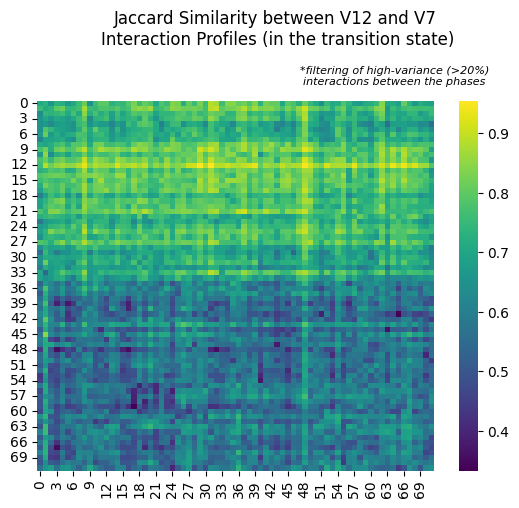

In [113]:
#plot jaccard sililarity heatmap
import seaborn as sns
import matplotlib.pyplot as plt
fig = plt.figure()
sns.heatmap(jaccard_sim, annot=False, cmap='viridis')
plt.suptitle('Jaccard Similarity between V12 and V7 \nInteraction Profiles (in the transition state)', fontdict=font, x=0.5, y=1.07)
#make_space_above(fig, topmargin=1)  
plt.title('\n*filtering of high-variance (>20%)\ninteractions between the phases', fontdict=font1, x=0.9, y=1.02)
plt.show()

In [114]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
import seaborn as sns

# Pass the condensed vector to linkage. 
# drop the metric="euclidean" argument because the distances are already calculated!
complete_clustering = linkage(jaccard_sim, method="complete")

In [128]:
number_of_labels = jaccard_sim.shape[0]
colors = plt.cm.rainbow(np.linspace(0, 1, number_of_labels))


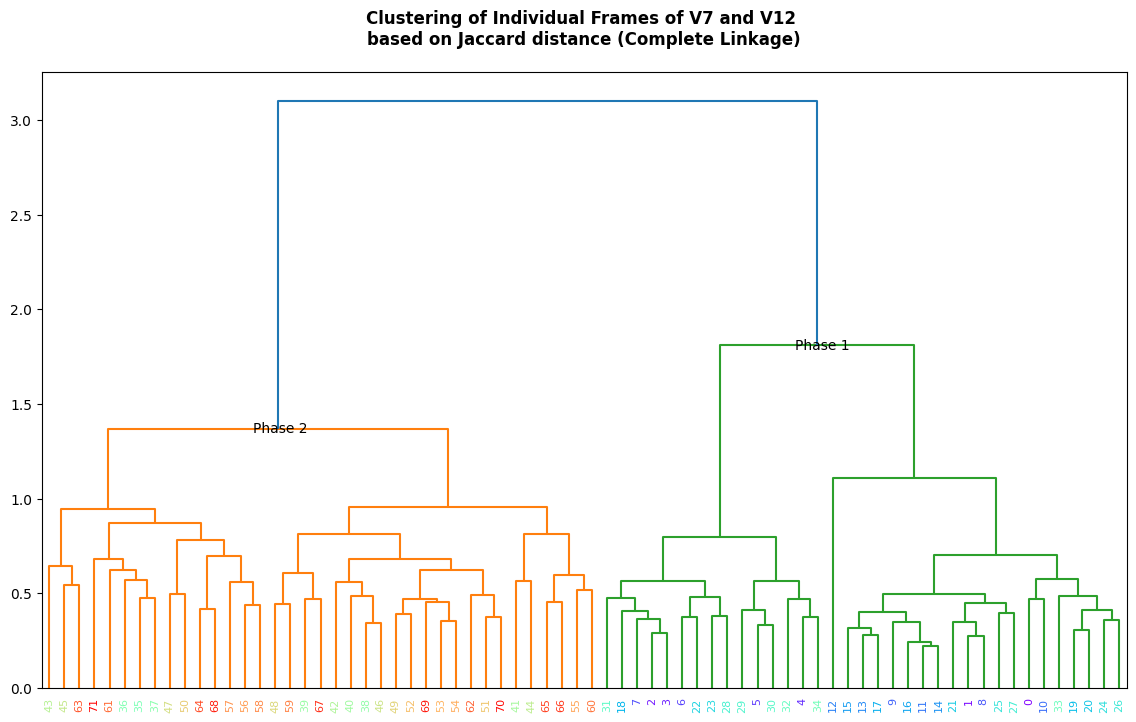

In [160]:
fig, ax = plt.subplots(figsize=(14,8))
dendrogram(complete_clustering, leaf_font_size=8, orientation='top')

plt.title("Clustering of Individual Frames of V7 and V12 \nbased on Jaccard distance (Complete Linkage)",
        fontsize=12, fontweight='bold', pad=20)
xlbls = ax.get_xmajorticklabels()
#color labels in rainow as frames progress
for lbl in xlbls:
        lbl.set_color(colors[int(lbl.get_text())])    

#annotate phase 1 and phase 2 regions on the dendrogram
plt.annotate('Phase 2', xy=(130, 1.35), xytext=(140, 1.35))
plt.annotate('Phase 1', xy=(500, 1.77), xytext=(500, 1.79))
plt.show()

In [ ]:
for i in list(df_full.index):
    if i between  > PHASE_LIMITS['V7']:
        print(f"Frame {i} is in phase 2")

,hbbb_ASN_40_O_TYR_42_N,hbsb_GLY_138_O_TYR_158_OH,hbss_ASN_98_ND2_SER_195_OG,hbsb_ASP_25_OD1_GLY_126_N,hbss_GLU_136_OE2_THR_176_OG1,hbss_ARG_87_NH2_ASP_29_OD2,hbsb_ALA_28_N_ASP_25_OD2,hbsb_ARG_87_NE_GLY_27_O,hbbb_ALA_191_N_ASN_187_O,hbss_ARG_107_NE_ASP_29_OD2,...,hbsb_GLY_39_O_TYR_59_OH,hbss_ARG_107_NH2_ASP_29_OD2,hbbb_ARG_8_O_VAL_10_N,hbbb_GLY_35_N_VAL_33_O,hbsb_ASP_25_OD1_THR_125_N,hbsb_ARG_87_NH1_LEU_104_O,hbss_ARG_171_NE_ASN_160_OD1,hbsb_ILE_36_O_THR_77_OG1,hbsb_ARG_171_NH2_ASN_160_O,hbbb_ALA_92_N_ILE_89_O
163,0,1,1,0,0,0,0,1,0,0,...,0,0,0,1,0,1,1,1,1,1
164,0,1,0,0,0,0,0,1,1,0,...,0,0,0,1,0,1,1,1,1,0
165,0,1,0,0,0,0,0,1,1,0,...,0,0,1,1,0,1,1,1,1,0
166,0,1,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,1,1,1,1
167,0,1,0,0,0,0,0,1,1,0,...,0,0,0,1,0,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,1,1,0,1,1
68,1,1,1,0,0,0,0,1,0,0,...,1,1,0,0,0,1,0,0,1,1
69,1,1,1,0,0,0,0,1,0,1,...,1,1,0,0,0,1,0,0,1,1
70,1,1,1,0,0,1,1,0,0,1,...,1,0,0,0,0,1,1,0,1,1


In [117]:
jaccard_df = pd.DataFrame(jaccard_sim)

In [118]:
jaccard_df

,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,0.714286,0.731707,0.658537,0.733333,0.720930,0.666667,0.704545,0.756098,0.809524,0.650000,...,0.840909,0.711111,0.714286,0.682927,0.804348,0.731707,0.666667,0.720930,0.695652,0.688889
1,0.755556,0.714286,0.733333,0.795918,0.812500,0.739130,0.744681,0.767442,0.869565,0.755556,...,0.847826,0.666667,0.755556,0.727273,0.760870,0.772727,0.765957,0.760870,0.760000,0.755102
2,0.634146,0.744186,0.733333,0.744681,0.760870,0.711111,0.770833,0.707317,0.844444,0.727273,...,0.822222,0.666667,0.727273,0.697674,0.704545,0.744186,0.739130,0.674419,0.708333,0.755102
3,0.659091,0.704545,0.666667,0.708333,0.695652,0.673913,0.708333,0.755556,0.804348,0.627907,...,0.808511,0.687500,0.744681,0.688889,0.723404,0.704545,0.729167,0.723404,0.700000,0.720000
4,0.651163,0.666667,0.627907,0.673913,0.688889,0.666667,0.644444,0.750000,0.772727,0.651163,...,0.690476,0.558140,0.681818,0.681818,0.688889,0.666667,0.666667,0.627907,0.638298,0.568182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.512821,0.727273,0.487179,0.351351,0.487179,0.461538,0.512195,0.589744,0.540541,0.550000,...,0.589744,0.622222,0.681818,0.550000,0.595238,0.666667,0.604651,0.627907,0.511628,0.463415
68,0.615385,0.731707,0.472222,0.459459,0.589744,0.486486,0.459459,0.621622,0.611111,0.615385,...,0.621622,0.651163,0.682927,0.578947,0.690476,0.666667,0.600000,0.589744,0.461538,0.487179
69,0.513514,0.707317,0.444444,0.432432,0.564103,0.459459,0.512821,0.631579,0.583333,0.625000,...,0.594595,0.560976,0.625000,0.589744,0.634146,0.641026,0.538462,0.564103,0.512195,0.571429
70,0.500000,0.638889,0.514286,0.500000,0.555556,0.605263,0.578947,0.588235,0.531250,0.621622,...,0.588235,0.552632,0.621622,0.583333,0.631579,0.600000,0.641026,0.594595,0.575000,0.600000


In [188]:
limit_V12 - 35

0

In [194]:
df_full = pd.DataFrame()
df_full = pd.concat([V7_df, V12_df])

# phase label
limit_V7 = PHASE_LIMITS['V7']
limit_V12 = PHASE_LIMITS['V12']
label = []
for frame in list(df_full.index):
    if frame in range(0, limit_V12 + 1):
        label.append(f"Phase 1")
    elif frame in range(limit_V7 - 35, limit_V7 + 1):
        label.append(f"Phase 1")
    else:
        label.append(f"Phase 2")
        
#df_full["Label"] = label

In [207]:
#Decision tree to predict phase based on interactions
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
V7_df['Phase'] = ['Phase 1' if f <= limit_V7 else 'Phase 2' for f in V7_df.index]
V12_df['Phase'] = ['Phase 1' if f <= limit_V12 else 'Phase 2' for f in V12_df.index]

df_full = pd.concat([V7_df, V12_df], ignore_index=True)

X = df_full.drop(columns=['Phase'])
y = df_full['Phase'].tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [204]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     Phase 1       0.82      0.93      0.88        15
     Phase 2       0.92      0.79      0.85        14

    accuracy                           0.86        29
   macro avg       0.87      0.86      0.86        29
weighted avg       0.87      0.86      0.86        29



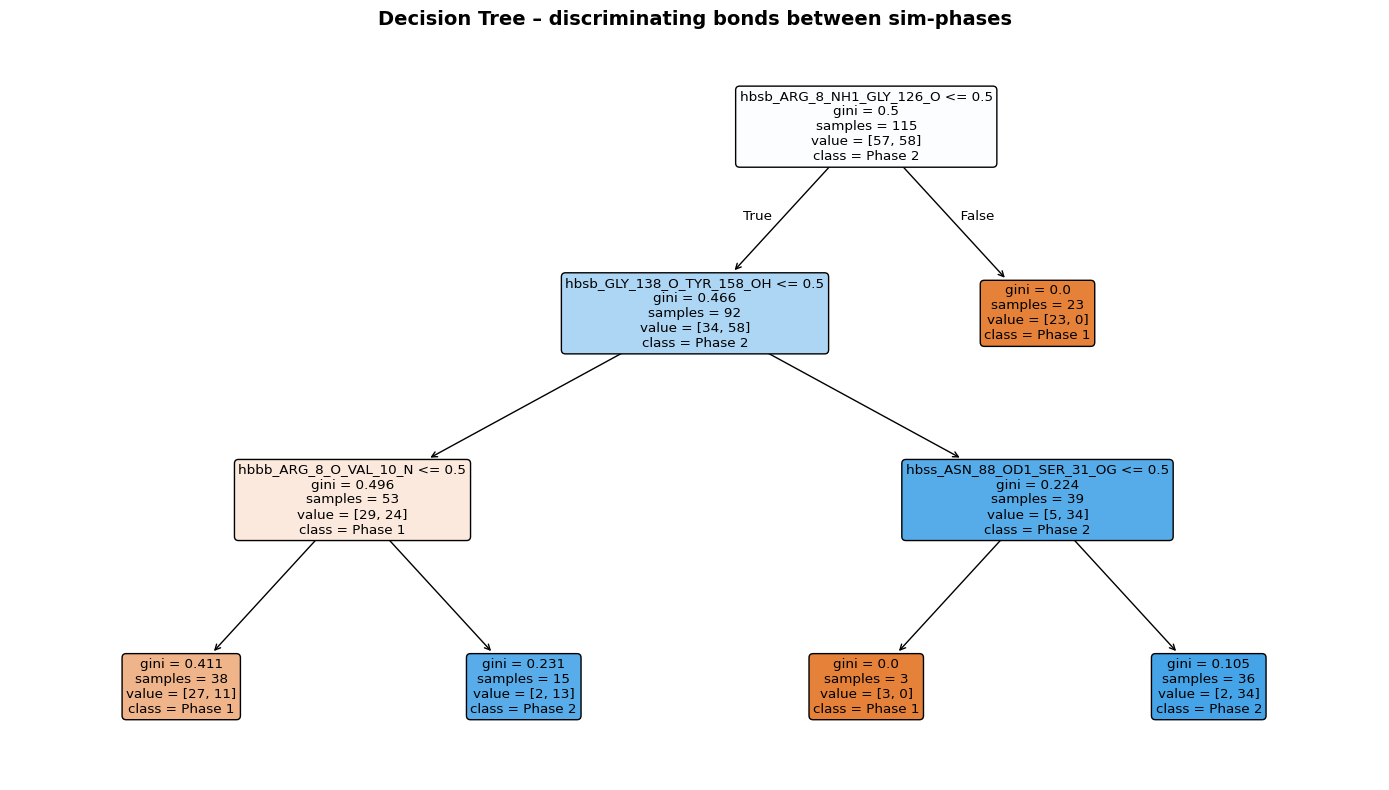

In [206]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from io import StringIO

fig, ax = plt.subplots(figsize=(14, 8))
plot_tree(clf, 
          feature_names=X.columns.tolist(),
          class_names=clf.classes_.tolist(),
          filled=True, 
          rounded=True,
          proportion=False,
          ax=ax)

ax.set_title('Decision Tree – discriminating bonds between sim-phases', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'decision_tree.png'), dpi=150, bbox_inches='tight')
plt.show()


In [217]:
# check if asp25-asp124 is still in the df
resid_list = ['26','125']
asp_check = [col for col in df_full.columns if all(resid in col for resid in resid_list)]

In [218]:
asp_check

['hbss_THR_125_OG1_THR_26_OG1', 'hbsb_THR_125_N_THR_26_OG1']